# 📘 Tutorial: Understanding and Visualizing Real COLMAP (SfM) Outputs

This tutorial explains the core data structures produced by **COLMAP (Structure-from-Motion)** and directly visualizes each component using **real data** from the **IC-SHM 2026 Project 2 Contest Dataset** (`data/Contest Dataset/`).

---

### 📑 Table of Contents:
1. **Overview of Core COLMAP Files** (`cameras.txt`, `images.txt`)
2. **Real `cameras.txt`**: Camera Intrinsics Matrix $K$, Focal Length $f$, Principal Point $(c_x, c_y)$, and Radial Lens Distortion $k_1$
3. **Real `images.txt`**: 400 Camera Poses, Quaternion $\to$ Rotation Matrix $R$, and World Camera Positions $C = -R^T T$
4. **Real 2D Feature Observations**: Overlaying matched vs. unmatched SIFT keypoints on actual UAV image frames
5. **Real Multi-View Feature Tracks**: Analyzing track length distribution across 86,336 points
6. **Full 3D Scene Visualization**: Real UAV Flight Trajectory (400 cameras) + 3D Triangulation Sight Rays

In [1]:
import os
import sys
from collections import Counter
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.transform import Rotation

# Set project paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "data", "Contest Dataset")
CAM_FILE = os.path.join(DATA_DIR, "camera_parameters", "cameras.txt")
IMG_FILE = os.path.join(DATA_DIR, "camera_parameters", "images.txt")
IMAGES_DIR = os.path.join(DATA_DIR, "images")

# Configure plotting aesthetics
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"✅ Base Directory: {BASE_DIR}")
print(f"✅ Dataset Directory: {DATA_DIR}")
assert os.path.exists(CAM_FILE), f"Cannot find cameras.txt at {CAM_FILE}"
assert os.path.exists(IMG_FILE), f"Cannot find images.txt at {IMG_FILE}"

✅ Base Directory: /home/zeki/ic-shm-2026-project-2
✅ Dataset Directory: /home/zeki/ic-shm-2026-project-2/data/Contest Dataset


## 1. What Does COLMAP Output?

After running Structure-from-Motion (SfM) on multi-view UAV images, COLMAP produces **purely geometric outputs**:

| File | Concept | Mathematical Meaning |
| :--- | :--- | :--- |
| `cameras.txt` | **Camera Intrinsics** | Internal optical parameters (focal length $f$, principal point $(c_x, c_y)$, radial distortion $k_1$). |
| `images.txt` | **Camera Extrinsics & 2D Tracks** | 6-DOF camera poses ($Q, T$) + sequence of 2D keypoints $(u, v)$ with 3D point track IDs. |

> 💡 **Note**: COLMAP is semantically blind. It reconstructs geometry $(x, y, z)$ and camera poses without structural labels (`deck`, `tower`, `stay_cable`, `foundation`). Our pipeline bridges this gap by mapping 2D AI segmentations to these 3D feature tracks.

## 2. Exploring Real `cameras.txt` (Camera Intrinsics)

Let us read and parse the real `cameras.txt` provided in the competition dataset.

📐 Camera ID: 1 | Model: SIMPLE_RADIAL
   • Resolution: 1320 x 989 px
   • Focal Length f: 925.7016 px
   • Principal Point (cx, cy): (660.0, 494.5) px
   • Radial Distortion k1: 0.00898786

🔍 Camera Intrinsics Matrix K:
[[925.70161892   0.         660.        ]
 [  0.         925.70161892 494.5       ]
 [  0.           0.           1.        ]]


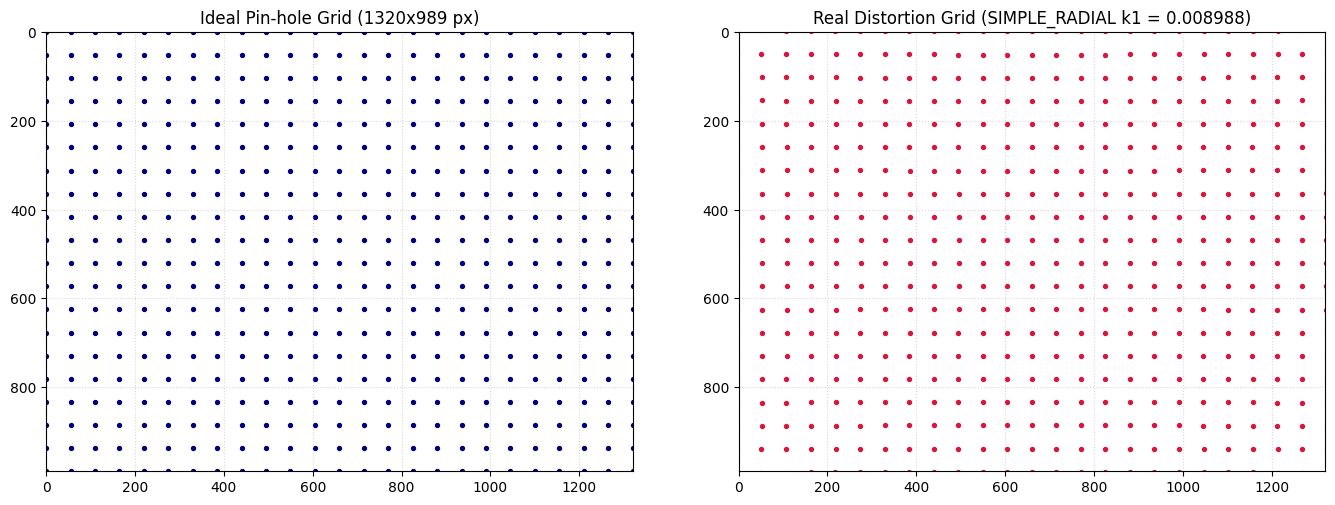

In [2]:
# 1. Parse real cameras.txt
with open(CAM_FILE, "r") as f:
    cam_lines = [l.strip() for l in f if l.strip() and not l.startswith("#")]

parts = cam_lines[0].split()
cam_id = int(parts[0])
model_name = parts[1]
width = int(parts[2])
height = int(parts[3])
focal_length = float(parts[4])
cx = float(parts[5])
cy = float(parts[6])
k1 = float(parts[7])

# 2. Build 3x3 Intrinsics Matrix K
K = np.array([
    [focal_length, 0.0, cx],
    [0.0, focal_length, cy],
    [0.0, 0.0, 1.0]
])

print(f"📐 Camera ID: {cam_id} | Model: {model_name}")
print(f"   • Resolution: {width} x {height} px")
print(f"   • Focal Length f: {focal_length:.4f} px")
print(f"   • Principal Point (cx, cy): ({cx:.1f}, {cy:.1f}) px")
print(f"   • Radial Distortion k1: {k1:.8f}")
print("\n🔍 Camera Intrinsics Matrix K:")
print(K)

# 3. Visualize the real radial lens distortion displacement
gx, gy = np.meshgrid(np.linspace(0, width, 25), np.linspace(0, height, 20))
u_norm = (gx - cx) / focal_length
v_norm = (gy - cy) / focal_length
r2 = u_norm**2 + v_norm**2
u_dist = gx + (gx - cx) * k1 * r2
v_dist = gy + (gy - cy) * k1 * r2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(gx, gy, c='navy', s=8)
ax1.set_title(f"Ideal Pin-hole Grid ({width}x{height} px)")
ax1.set_xlim(0, width); ax1.set_ylim(height, 0); ax1.set_aspect('equal'); ax1.grid(True, linestyle=':', alpha=0.5)

ax2.scatter(u_dist, v_dist, c='crimson', s=8)
ax2.set_title(f"Real Distortion Grid (SIMPLE_RADIAL k1 = {k1:.6f})")
ax2.set_xlim(0, width); ax2.set_ylim(height, 0); ax2.set_aspect('equal'); ax2.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Exploring Real `images.txt` (Camera Extrinsics & Flight Poses)

In `images.txt`, each registered image has:
- **Line 1 (6-DOF Extrinsic Pose)**: `IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME`
  - Rotation Matrix $R$ converted from Quaternion $[q_w, q_x, q_y, q_z]$
  - Translation Vector $T = [t_x, t_y, t_z]$
  - **World Camera Position**: $C = -R^T \cdot T$
- **Line 2 (2D Observations)**: Triplets `X_pixel, Y_pixel, POINT3D_ID`
  - `POINT3D_ID = -1`: SIFT feature detected but not triangulated.
  - `POINT3D_ID >= 0`: SIFT feature matched into a triangulated 3D point.

In [3]:
# Parse real images.txt
images = {}
points2d_per_image = {}
point3d_to_observations = {}

with open(IMG_FILE, "r") as f:
    lines = [l.strip() for l in f if l.strip() and not l.startswith("#")]

for i in range(0, len(lines), 2):
    pose_line = lines[i].split()
    image_id = int(pose_line[0])
    qw, qx, qy, qz = map(float, pose_line[1:5])
    tx, ty, tz = map(float, pose_line[5:8])
    cam_id_entry = int(pose_line[8])
    img_name = pose_line[9]
    
    # Convert Quaternion to 3x3 Rotation Matrix R
    rot = Rotation.from_quat([qx, qy, qz, qw]).as_matrix()
    tvec = np.array([tx, ty, tz])
    
    # Calculate true physical UAV Camera Center in World Coordinates: C = -R^T * T
    center = -rot.T @ tvec
    
    images[image_id] = {
        "name": img_name,
        "rot": rot,
        "tvec": tvec,
        "center": center,
        "quat": (qw, qx, qy, qz)
    }
    
    # Parse 2D keypoints
    pts_line = lines[i+1].split()
    pts = []
    for k in range(0, len(pts_line), 3):
        u = float(pts_line[k])
        v = float(pts_line[k+1])
        p3d = int(pts_line[k+2])
        pts.append((u, v, p3d))
        if p3d >= 0:
            if p3d not in point3d_to_observations:
                point3d_to_observations[p3d] = []
            point3d_to_observations[p3d].append((image_id, u, v))
    points2d_per_image[image_id] = pts

centers = np.array([img["center"] for img in images.values()])
print(f"✅ Successfully parsed {len(images)} registered UAV camera frames!")
print(f"📊 Total 2D observations: {sum(len(pts) for pts in points2d_per_image.values()):,}")
print(f"🔗 Unique 3D feature tracks: {len(point3d_to_observations):,}")
print(f"📍 UAV Flight Trajectory Range (meters):")
print(f"   • X: [{centers[:,0].min():.2f}, {centers[:,0].max():.2f}] m")
print(f"   • Y: [{centers[:,1].min():.2f}, {centers[:,1].max():.2f}] m")
print(f"   • Z: [{centers[:,2].min():.2f}, {centers[:,2].max():.2f}] m")

✅ Successfully parsed 400 registered UAV camera frames!
📊 Total 2D observations: 1,708,271
🔗 Unique 3D feature tracks: 86,336
📍 UAV Flight Trajectory Range (meters):
   • X: [-3.44, 6.36] m
   • Y: [-0.79, 0.83] m
   • Z: [-5.36, 6.80] m


## 4. Overlaying Real 2D SIFT Keypoints on an Actual UAV Image Frame

Let us load `data/Contest Dataset/images/001.png` and overlay the real feature points extracted by COLMAP onto the actual image canvas:
- 🟢 **Green points (`POINT3D_ID >= 0`)**: Keypoints that successfully triangulated into 3D points.
- ⚪ **Grey points (`POINT3D_ID == -1`)**: Unmatched 2D features.

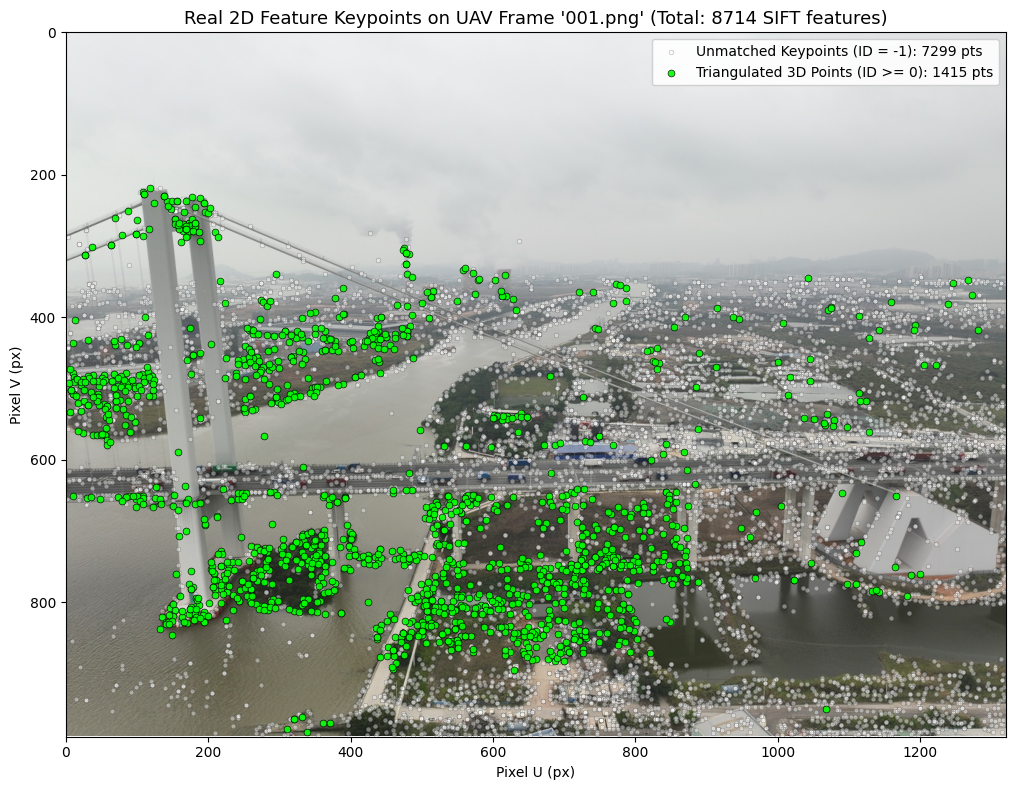

In [4]:
# Select a sample image
sample_img_name = "001.png"
sample_img_path = os.path.join(IMAGES_DIR, sample_img_name)

# Find corresponding image_id in parsed images.txt
sample_img_id = [img_id for img_id, data in images.items() if data["name"] == sample_img_name][0]
raw_pts = points2d_per_image[sample_img_id]

u_coords = np.array([p[0] for p in raw_pts])
v_coords = np.array([p[1] for p in raw_pts])
p3d_ids = np.array([p[2] for p in raw_pts])

matched_mask = p3d_ids >= 0
unmatched_mask = p3d_ids == -1

# Load real image
uav_img = Image.open(sample_img_path)

plt.figure(figsize=(14, 8))
plt.imshow(uav_img)

# Overlay unmatched 2D keypoints
plt.scatter(u_coords[unmatched_mask], v_coords[unmatched_mask], c='white', s=12, alpha=0.4,
            edgecolors='black', linewidth=0.3, label=f"Unmatched Keypoints (ID = -1): {np.sum(unmatched_mask)} pts")

# Overlay triangulated 3D points
plt.scatter(u_coords[matched_mask], v_coords[matched_mask], c='lime', s=24, alpha=0.9,
            edgecolors='black', linewidth=0.5, label=f"Triangulated 3D Points (ID >= 0): {np.sum(matched_mask)} pts")

plt.title(f"Real 2D Feature Keypoints on UAV Frame '{sample_img_name}' (Total: {len(raw_pts)} SIFT features)", fontsize=13)
plt.xlabel("Pixel U (px)"); plt.ylabel("Pixel V (px)")
plt.xlim(0, width); plt.ylim(height, 0)
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

## 5. Analyzing Real Multi-View Feature Tracks

A **feature track** is the set of all 2D observations $(u_k, v_k)$ across different drone images that correspond to the exact same physical 3D point $X_i$.

Points observed across **more camera views** provide stronger geometric triangulation certainty and more votes during 2D-to-3D semantic majority voting.

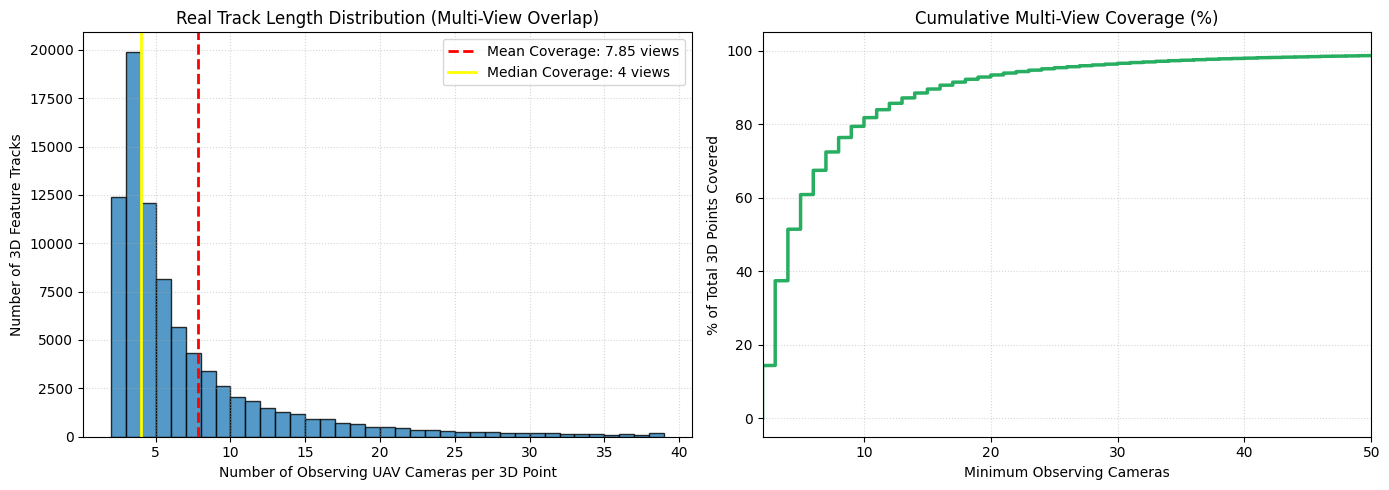

📊 Statistical Summary of Real Feature Tracks:
   • Min Views: 2 | Max Views: 206
   • Points observed by >= 5 cameras: 48.6%
   • Points observed by >= 10 cameras: 20.6%


In [6]:
# Compute track length distribution from real feature tracks
track_lengths = np.array([len(obs) for obs in point3d_to_observations.values()])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: Track length distribution
ax1.hist(track_lengths, bins=range(2, 40), color='#2980b9', edgecolor='black', alpha=0.8)
ax1.axvline(np.mean(track_lengths), color='red', linestyle='--', linewidth=2, 
            label=f"Mean Coverage: {np.mean(track_lengths):.2f} views")
ax1.axvline(np.median(track_lengths), color='yellow', linestyle='-', linewidth=2, 
            label=f"Median Coverage: {np.median(track_lengths):.0f} views")
ax1.set_title("Real Track Length Distribution (Multi-View Overlap)", fontsize=12)
ax1.set_xlabel("Number of Observing UAV Cameras per 3D Point")
ax1.set_ylabel("Number of 3D Feature Tracks")
ax1.legend(); ax1.grid(True, linestyle=':', alpha=0.5)

# Cumulative Distribution Function (CDF)
sorted_lengths = np.sort(track_lengths)
cdf = np.arange(len(sorted_lengths)) / float(len(sorted_lengths))
ax2.plot(sorted_lengths, cdf * 100, color='#27ae60', linewidth=2.5)
ax2.set_xlim(2, 50)
ax2.set_title("Cumulative Multi-View Coverage (%)", fontsize=12)
ax2.set_xlabel("Minimum Observing Cameras")
ax2.set_ylabel("% of Total 3D Points Covered")
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"📊 Statistical Summary of Real Feature Tracks:")
print(f"   • Min Views: {np.min(track_lengths)} | Max Views: {np.max(track_lengths)}")
print(f"   • Points observed by >= 5 cameras: {np.mean(track_lengths >= 5)*100:.1f}%")
print(f"   • Points observed by >= 10 cameras: {np.mean(track_lengths >= 10)*100:.1f}%")

## 6. Full 3D Scene: Real UAV Flight Trajectory & Triangulation Rays

Here we visualize the **real 3D scene**:
1. **400 Real UAV Camera Positions ($C = -R^T T$)** showing the drone's actual flight path around the bridge.
2. **Real Multi-View Triangulation Rays**: Optical rays drawn from multiple drone camera centers converging onto a real triangulated 3D point.

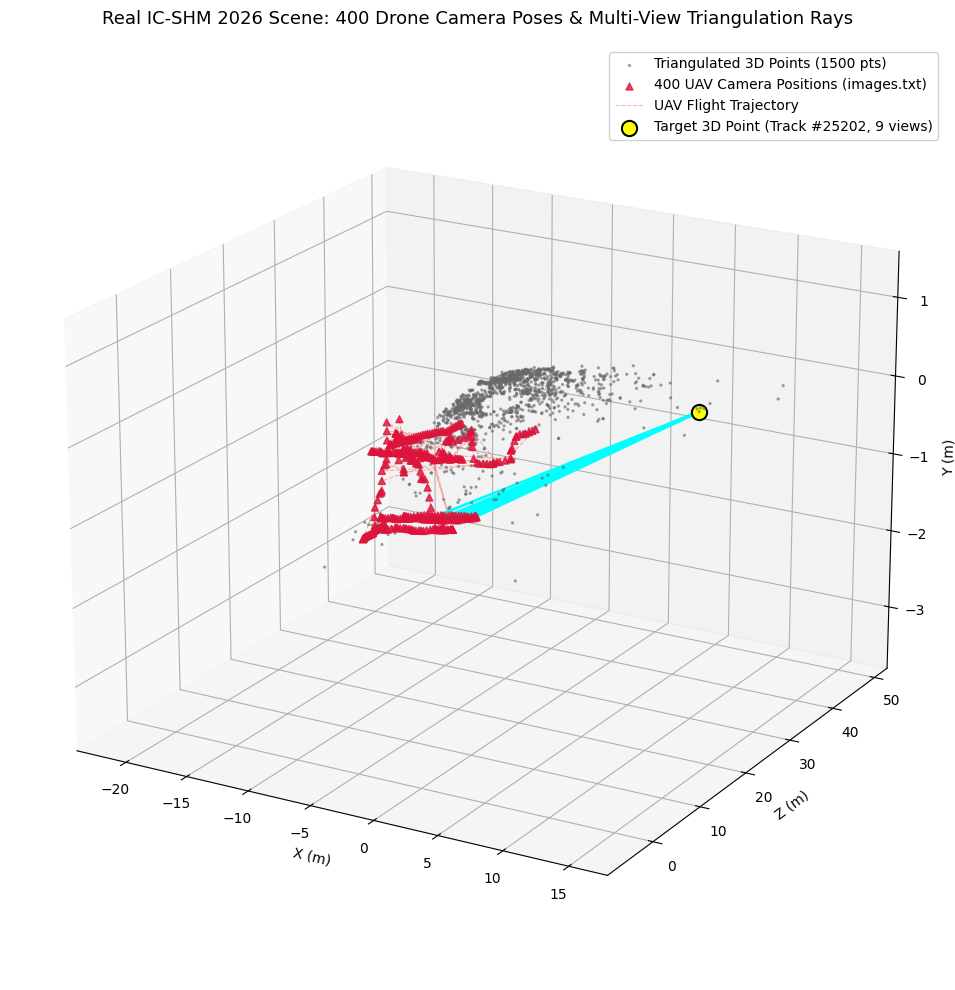

In [7]:
# 1. Direct Linear Transform (DLT) Triangulation function
def triangulate_dlt(obs_list):
    A = []
    for img_id, u, v in obs_list:
        R = images[img_id]["rot"]
        t = images[img_id]["tvec"]
        P = K @ np.hstack([R, t.reshape(3, 1)])
        A.append(u * P[2, :] - P[0, :])
        A.append(v * P[2, :] - P[1, :])
    A = np.array(A)
    _, _, Vh = np.linalg.svd(A)
    X = Vh[-1]
    return X[:3] / X[3]

# Triangulate sample 3D points from real tracks (obs >= 4 views)
sample_tracks = [p_id for p_id, obs in point3d_to_observations.items() if len(obs) >= 6]
triangulated_cloud = []
for p_id in sample_tracks[:1500]:
    pt3d = triangulate_dlt(point3d_to_observations[p_id])
    # Filter extreme numerical outliers
    if np.all(np.abs(pt3d) < 50):
        triangulated_cloud.append(pt3d)
triangulated_cloud = np.array(triangulated_cloud)

# Pick one representative 3D point observed by multiple cameras
target_track_id = sample_tracks[10]
target_obs = point3d_to_observations[target_track_id]
target_3d_pt = triangulate_dlt(target_obs)

# 2. Plot 3D Scene with Matplotlib 3D
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot triangulated sparse points
ax.scatter(triangulated_cloud[:, 0], triangulated_cloud[:, 2], triangulated_cloud[:, 1], 
           c='dimgray', s=2.0, alpha=0.5, label=f"Triangulated 3D Points ({len(triangulated_cloud)} pts)")

# Plot all 400 real UAV camera positions
ax.scatter(centers[:, 0], centers[:, 2], centers[:, 1], 
           c='crimson', s=25, marker='^', alpha=0.8, label=f"400 UAV Camera Positions (images.txt)")
ax.plot(centers[:, 0], centers[:, 2], centers[:, 1], 'r--', alpha=0.3, linewidth=0.8, label="UAV Flight Trajectory")

# Draw optical triangulation rays from observing cameras to the target point
for img_id, u, v in target_obs:
    cam_c = images[img_id]["center"]
    ax.plot([cam_c[0], target_3d_pt[0]], [cam_c[2], target_3d_pt[2]], [cam_c[1], target_3d_pt[1]],
            color='cyan', linewidth=2.0, linestyle='-')

# Highlight the intersection 3D point
ax.scatter([target_3d_pt[0]], [target_3d_pt[2]], [target_3d_pt[1]], 
           color='yellow', s=120, edgecolors='black', linewidth=1.5, 
           label=f"Target 3D Point (Track #{target_track_id}, {len(target_obs)} views)", zorder=10)

ax.set_title("Real IC-SHM 2026 Scene: 400 Drone Camera Poses & Multi-View Triangulation Rays", fontsize=13, pad=15)
ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m)")
ax.set_zlabel("Y (m)")
ax.legend(loc='upper right', framealpha=0.9)
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

---
## 🎯 Summary of Key Learnings on Real COLMAP Data:

1. **Real Camera Model**: The competition uses a calibrated `SIMPLE_RADIAL` camera ($1320 \times 989$) with focal length $f \approx 925.7\text{ px}$ and radial distortion $k_1 \approx 0.008988$.
2. **400 Registered Poses**: All 400 images (300 labeled + 100 unlabeled) have reconstructed 6-DOF camera poses covering the entire bridge structure.
3. **86,336 3D Feature Tracks**: With an average of $7.85$ camera views per track, multi-view majority voting has strong statistical support across camera angles to filter 2D segmentation noise.